# Lab 01 - Evasion attacks

In this laboratory, we will undestand how to write an evasion attack in Pytorch, using gradient-descent, and how to load attacks with SecML Torch.


In [127]:
try:
    import secmlt
    import sklearn
    import matplotlib
    import foolbox
except ImportError:
    print("Installing the dependancies")
    %pip install git+https://github.com/pralab/secml-torch
    %pip install scikit-learn
    %pip install matplotlib
    %pip install foolbox



As seen in class, machine learning models can be fooled by *adversarial examples*, samples artificially crafted to redirect the output of the victim towards a desired result.

These attacks can be either:

* **targeted**, in which the attacker wants to produce a specific misclassification (e.g. a dog must be recognized as a cat); or
* **untargeted**, in which the attacker is satisfied with producing a generic misclassification (e.g. a dog will be recognized as anything else but a dog).

Both targeted and untargeted attacks are formulated as optimization problems.

### Targeted attacks

Targeted attacks that can be written as:

$$
  \min_{\boldsymbol{\delta}} L(\boldsymbol{x} + \boldsymbol{\delta}, y_t; \boldsymbol{\theta})
  \\
  s.t.\quad ||\delta||_p \le \epsilon
  \\
  \text{subject to} \quad \boldsymbol{l}_b \preccurlyeq \boldsymbol{x} + \boldsymbol{\delta} \preccurlyeq \boldsymbol{l}_u
$$

where $L$ is the objective function of our attack (it defines the goal of the attacker, *i.e.*, where to find adversarial examples), $\boldsymbol{x}$ is the sample to perturb, $y_t$ is the target label, $\boldsymbol{\theta}$ are the parameters of the model, $\epsilon$ is the maximum allowed perturbation, and $\boldsymbol{l}_b,\boldsymbol{l}_u$ are the input-space bounds (for instance, images must be clipped in 0-1 or 0-255 to be valid samples).


### Untargeted attacks

Untargeted attacks can be formulated as:

$$
  \max_{\boldsymbol{\delta}} L(\boldsymbol{x} + \boldsymbol{\delta}, y; \boldsymbol{\theta})
  \\
  s.t.\quad ||\delta||_p \le \epsilon
  \\
  \text{subject to} \quad \boldsymbol{l}_b \preccurlyeq \boldsymbol{x} + \boldsymbol{\delta} \preccurlyeq \boldsymbol{l}_u
$$

where we change the minimization to a *maximization*, since we want to maximize the error of the classifier w.r.t. the real label $y$.

We start by implementing *untargeted* evasion attacks, and we need to define two main components: the *optimization algorithm* and the *loss function* of the attack. While the second one can be *any* distance function, we will now describe one particular optimizer.

[1] Biggio et al. "Evasion attacks against machine learning at test time", ECML PKDD 2013, https://arxiv.org/abs/1708.06131

[2] Madry et al. "Towards deep learning models resistant to adversarial attacks", ICLR 2018, https://arxiv.org/pdf/1706.06083.pdf

## Projected Gradient Descent

In this labroatory, we will leverage the *projected gradient descent* optimizer, by implementing it step by step in Pytorch.

![projected-gradient descent](assets/pgd_attack.png)

By following the same idea of gradient descent, we now implement an untargeted evasion attack in Pytorch.

In [128]:
import torch
def untargeted_l2_pgd(model, x, y, epsilon=0.3, alpha=0.01, num_iter=40, lb=-1, ub=1):
    """
    Perform untargeted PGD attack on an input sample.  
    Parameters:
        model: The neural network model to attack.
        x: The input sample to be perturbed (torch tensor).
        y: The true label of the input sample (torch tensor).
        epsilon: The maximum perturbation allowed (L2 norm).
        alpha: The step size for each iteration.
        num_iter: The number of iterations to perform.
    Returns:
        x_adv: The adversarially perturbed sample (torch tensor).
    """
    model.eval()
    delta = torch.zeros_like(x, requires_grad=True)
    deltas = torch.zeros((x.shape[0], num_iter) + x.shape[1:], device=x.device)
    for _ in range(num_iter):
        outputs = model(x + delta)
        loss = torch.nn.CrossEntropyLoss()(outputs, y)
        loss.backward()
        
        # Needed to avoid zero division during the normalization
        gradient = delta.grad.data / (delta.grad.data.norm() + 1e-10)

        # Gradient ascent step
        delta.data = delta + alpha * gradient
        
        # Project the perturbation to be within the L2 ball of radius epsilon
        if delta.data.norm() > epsilon:
            delta.data = epsilon * delta.data / delta.data.norm()

        # Clip the perturbation to keep the domain constraints
        delta.data = torch.clamp(delta.data, lb - x, ub - x)
        
        deltas[:, _] = delta.data
        
        delta.grad.zero_()
    return x.data + delta.data, deltas

We now thest our simple attack against a simple network (the same we developed in the previous lab.)

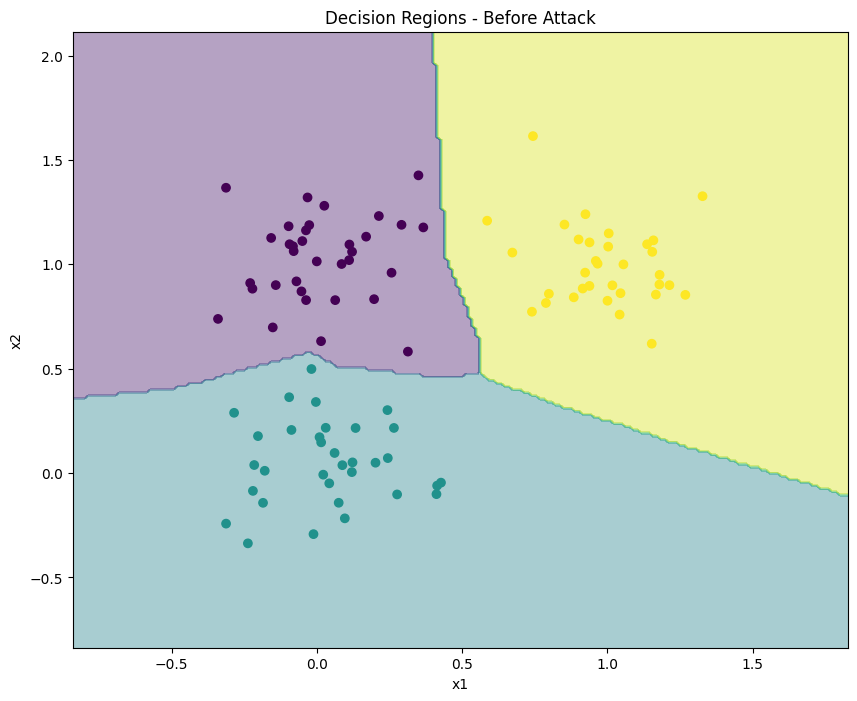

In [129]:
from secmlt.models.pytorch.base_pytorch_nn import BasePytorchClassifier
from secmlt.models.pytorch.base_pytorch_trainer import BasePyTorchTrainer
from torch.utils.data import DataLoader, TensorDataset
from sklearn.datasets import make_blobs
import numpy as np
import matplotlib.pyplot as plt

def plot_decision_regions(model, X, y, title="Decision Regions"):
    """
    Plot decision regions for a PyTorch model.
    
    Args:
        model: PyTorch model (must be in eval mode)
        X: Input features as tensor
        y: Labels as tensor
        title: Plot title
    """
    # Convert tensors to numpy for plotting
    X_np = X.detach().numpy()
    y_np = y.detach().numpy()
    
    # Create a mesh grid
    x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                        np.linspace(y_min, y_max, 200))
    
    # Get predictions for each point in the mesh
    X_mesh = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        model.eval()
        Z = model(X_mesh)
        Z = torch.argmax(Z, dim=1)
    Z = Z.numpy().reshape(xx.shape)
    
    # Plot decision regions
    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    
    # Plot data points
    scatter = plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, 
                         cmap='viridis')
    
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.show()

class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = torch.nn.Linear(2, 16)  # Input layer to hidden layer
        self.fc2 = torch.nn.Linear(16, 16) # Hidden layer to hidden layer
        self.fc3 = torch.nn.Linear(16, 3)  # Hidden layer to output layer
        self.relu = torch.nn.ReLU()         # ReLU activation function

    def forward(self, x):
        x = self.relu(self.fc1(x))  # Apply first layer and ReLU
        x = self.relu(self.fc2(x))  # Apply second layer and ReLU
        x = self.fc3(x)             # Apply output layer (no activation here)
        return x

X_train, y_train = make_blobs(n_samples=500, 
                  centers=[(0, 1), (0, 0), (1, 1)],
                  n_features=2,
                  cluster_std=0.2,
                  random_state=999)
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test, y_test = make_blobs(n_samples=100, 
                  centers=[(0, 1), (0, 0), (1, 1)],
                  n_features=2,
                  cluster_std=0.2,
                  random_state=999)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)


tr_dataloader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=False)
ts_dataloader = DataLoader(TensorDataset(X_test, y_test), batch_size=32, shuffle=False)

model = Net()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.CrossEntropyLoss()

trainer = BasePyTorchTrainer(optimizer=optimizer, loss=criterion, epochs=100)
secmlt_model = BasePytorchClassifier(model, trainer=trainer)
secmlt_model.train(tr_dataloader)

plot_decision_regions(model, X_test, y_test, title="Decision Regions - Before Attack")

In [130]:
# we execute the attack on a single sample
epsilon = 0.7
alpha = 1e-2
num_iter=500

x_advs, deltas = untargeted_l2_pgd(model, X_test[0,:], y_test[0], epsilon=epsilon, alpha=alpha, num_iter=num_iter, lb=-2,ub=2)
y_pred = model(x_advs).argmax(dim=-1)
print("Predicted label:", y_pred.item(), "\nReal label:",y_test[0].item())

Predicted label: 0 
Real label: 2


Since we also saved the deltas at each step, we can now plot its path with an helper function.

In [131]:
import numpy as np
import torch

def plot_attack_path(model, X, y, x_init, deltas, epsilon, title="Attack Path on Decision Regions"):
    """
    Plots decision regions, the initial sample as a green large circle, the attack path, and the last sample as a red cross. Optionally plots the L2 epsilon ball.

    Args:
        model: Trained PyTorch model.
        X: Input features (torch.Tensor) for decision region background.
        y: Labels (torch.Tensor) for coloring points.
        x_init: Initial sample (torch.Tensor, shape [2] or [1,2]).
        deltas: Attack deltas (torch.Tensor, shape [2, N] or [N, 2]).
        epsilon: (Optional) Radius of the L2 ball to plot.
        title: Plot title.
    """
    import matplotlib.pyplot as plt

    # Prepare mesh grid for decision regions
    X_np = X.detach().numpy()
    y_np = y.detach().numpy()
    x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    X_mesh = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        model.eval()
        Z = model(X_mesh)
        Z = torch.argmax(Z, dim=1)
    Z = Z.numpy().reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='viridis', edgecolor='k', s=30, alpha=0.7)

    # Initial sample as a green large circle
    x_init_np = x_init.detach().cpu().numpy()
    if x_init_np.ndim == 2:
        x_init_np = x_init_np[0]


    # Plot L2 epsilon ball if epsilon is provided
    if epsilon is not None:
        circle = plt.Circle((x_init_np[0], x_init_np[1]), epsilon, color='red', fill=False, linestyle='--', linewidth=2, label=f'L2 Ball (ε={epsilon})')
        plt.gca().add_patch(circle)

    # Compute attack path: x_init + deltas (assume deltas shape [2, N])
    if deltas.shape[0] == 2:
        path = x_init_np.reshape(2, 1) + deltas.detach().cpu().numpy()
        path = path.T
    else:
        path = x_init_np + deltas.detach().cpu().numpy()
    plt.plot(path[:, 0], path[:, 1], color='black', linewidth=2, marker='o', markersize=4, label='Attack Path')

    # Last sample as a red cross
    last_sample = path[-1]
    plt.scatter(x_init_np[0], x_init_np[1], marker='o', color='green', s=250, edgecolor='black', linewidths=2, label='Initial Sample', zorder = 2)
    plt.scatter(last_sample[0], last_sample[1], marker='x', color='red', s=200, linewidths=4, label='Final Sample', zorder = 2)
    
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

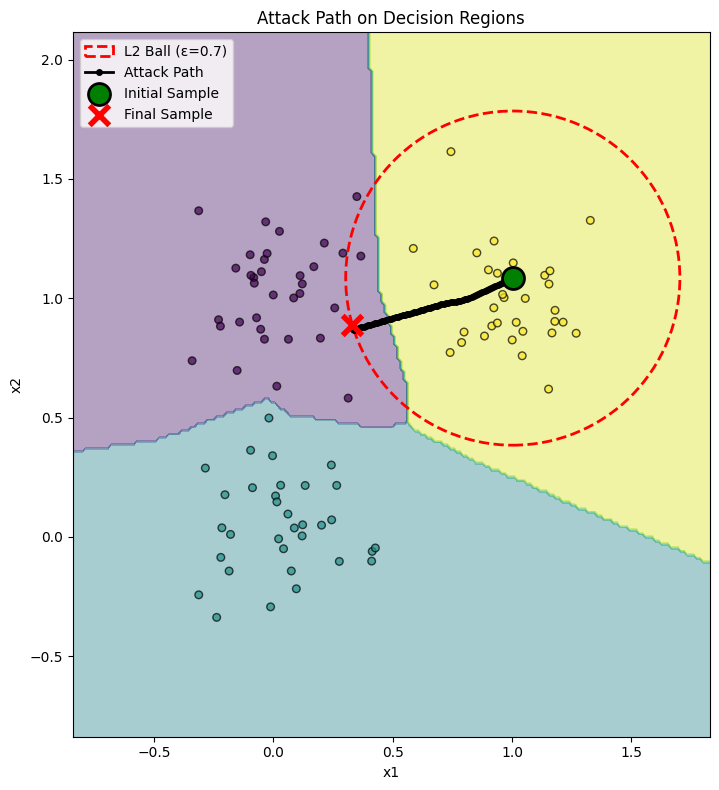

In [132]:
plot_attack_path(model, X_test, y_test, X_test[0,:], deltas, epsilon, title="Attack Path on Decision Regions")

### Exercise 1
* Try to change the parameters of the attack, and understand what they change in terms of the success of the attack.
* Create a function that produce **targeted** attacks, taking inspiration from the untargeted one.


--- Test 1: epsilon=0.1, alpha=0.005, iter=50 ---
Predicted: 2, True: 2 → ❌ Fallito


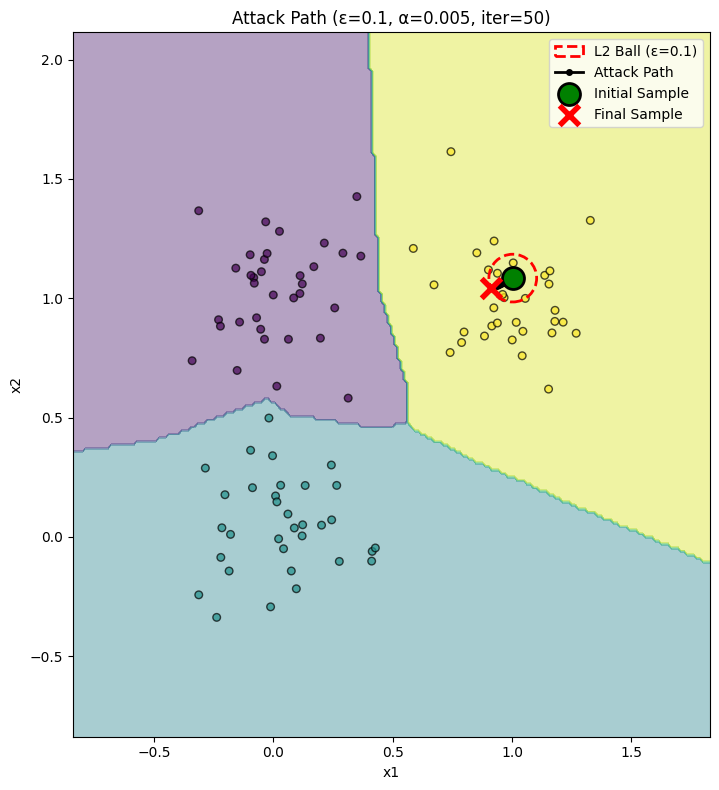


--- Test 2: epsilon=0.3, alpha=0.01, iter=100 ---
Predicted: 2, True: 2 → ❌ Fallito


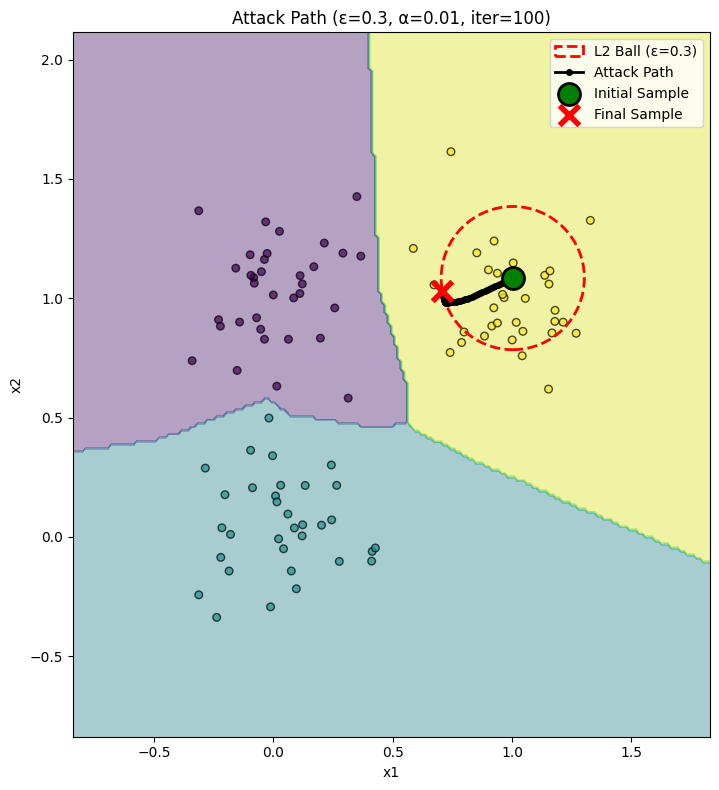


--- Test 3: epsilon=0.7, alpha=0.01, iter=300 ---
Predicted: 0, True: 2 → ✅ Successo


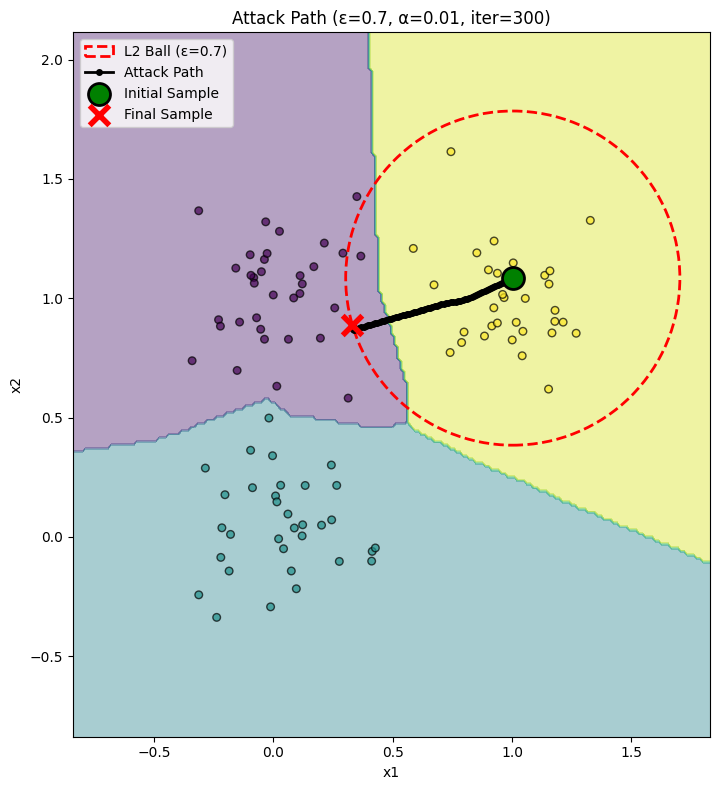


--- Test 4: epsilon=1.0, alpha=0.05, iter=50 ---
Predicted: 0, True: 2 → ✅ Successo


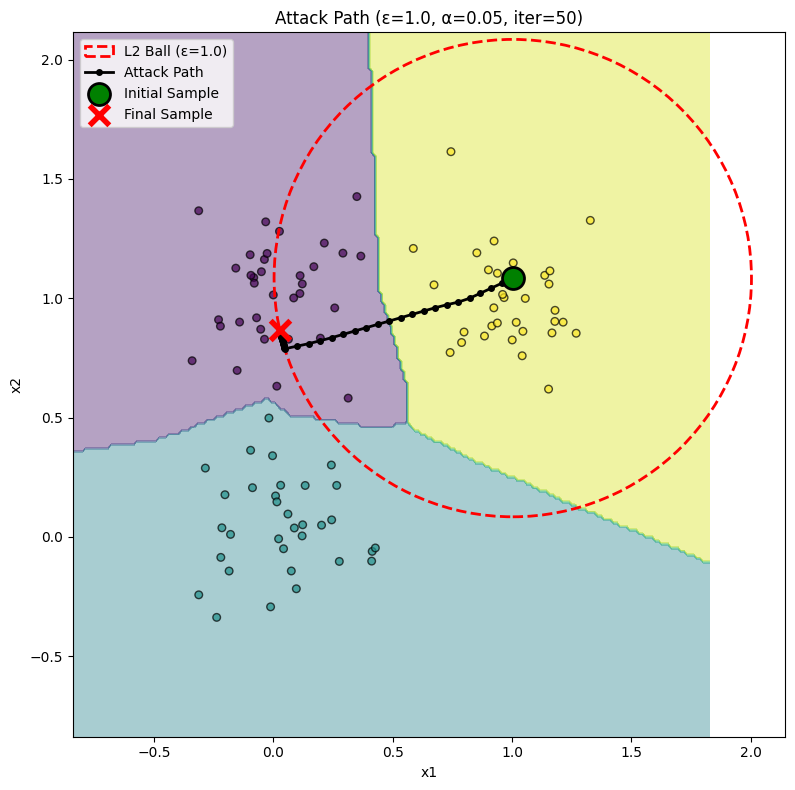

In [133]:
params = [
    {"epsilon": 0.1, "alpha": 0.005, "num_iter": 50},
    {"epsilon": 0.3, "alpha": 0.01,  "num_iter": 100},
    {"epsilon": 0.7, "alpha": 0.01,  "num_iter": 300},
    {"epsilon": 1.0, "alpha": 0.05,  "num_iter": 50},
]

# α is the step size taken at each iteration of the PGD attack.
    # Too few iterations → the gradient cannot find an effective direction.
 
# epsilon = 0.7
# alpha = 1e-2
# num_iter=500

x_init = X_test[0:1]
y_true = y_test[0:1]

for i, p in enumerate(params):
    print(f"\n--- Test {i+1}: epsilon={p['epsilon']}, alpha={p['alpha']}, iter={p['num_iter']} ---")
    
    x_adv, deltas = untargeted_l2_pgd(model, x_init, y_true,
                                      epsilon=p['epsilon'],
                                      alpha=p['alpha'],
                                      num_iter=p['num_iter'],
                                      lb=-2, ub=2)
    
    y_pred = model(x_adv).argmax(dim=-1)
    success = "✅ Successo" if y_pred.item() != y_true.item() else "❌ Fallito"
    print(f"Predicted: {y_pred.item()}, True: {y_true.item()} → {success}")
    
    plot_attack_path(model, X_test, y_test, x_init, deltas.squeeze(0), p['epsilon'],
                     title=f"Attack Path (ε={p['epsilon']}, α={p['alpha']}, iter={p['num_iter']})")



#### Targeted attacks
To switch from a targeted to a targeted PGD attack, two lines of editing are sufficient:

- replace y with y_t in the loss;
- reverse the sign of the gradient.

Note: Both reversing the loss and reversing the gradient work, but not together.

Predicted label: 1 
Real label: 2


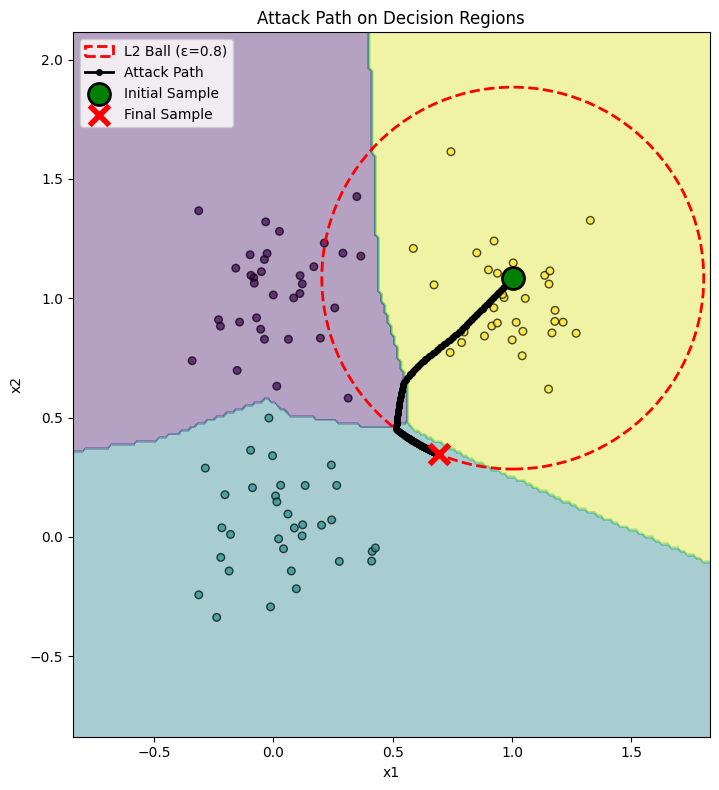

In [134]:
import torch
def targeted_l2_pgd(model, x, y_target, epsilon=0.3, alpha=0.01, num_iter=40, lb=-1, ub=1):

    model.eval()
    delta = torch.zeros_like(x, requires_grad=True)
    deltas = torch.zeros((x.shape[0], num_iter) + x.shape[1:], device=x.device)
    for _ in range(num_iter):
        outputs = model(x + delta)
        loss = torch.nn.CrossEntropyLoss()(outputs, y_target )  # Use target label here
        loss.backward()
        

        gradient = delta.grad.data / (delta.grad.data.norm() + 1e-10)


        delta.data = delta - alpha * gradient # Note the subtraction for targeted attack
        

        if delta.data.norm() > epsilon:
            delta.data = epsilon * delta.data / delta.data.norm()

   
        delta.data = torch.clamp(delta.data, lb - x, ub - x)
        
        deltas[:, _] = delta.data
        
        delta.grad.zero_()
        
    return x.data + delta.data, deltas


# we execute the attack on a single sample
epsilon = 0.8
alpha = 1e-2
num_iter=500


x_advs, deltas = targeted_l2_pgd(model, X_test[0,:], (y_test[0]-1)%3, epsilon=epsilon, alpha=alpha, num_iter=num_iter, lb=-2, ub=2) # Target class is 1
y_pred = model(x_advs).argmax(dim=-1)
print("Predicted label:", y_pred.item(), "\nReal label:",y_test[0].item())

plot_attack_path(model, X_test, y_test, X_test[0,:], deltas, epsilon, title="Attack Path on Decision Regions")


### My Notes


**PGD formulation**

The PGD (Projected Gradient Descent) attack is an iterative method based on gradient calculation:

1. Calculate the gradient of the loss with respect to 𝛿
2. Update 𝛿 following the direction of the gradient (maximization or minimization);
   - A change of sign in the gradient turns the targeted attack into a non-targeted one (and vice versa).
3. Project the new point inside the 𝐿𝑝 sphere (the “budget” of the attack);
4. Clip the values to respect the domain constraints;

Repeat until a predetermined number of iterations.

**Distance constraint**
$$\quad ||\delta||_p \le \epsilon$$

I am imposing a distance constraint on you: you can move within a circle of radius ε centred in x.

- If ε = 0 → you cannot move → no perturbation.
- If ε is very large → you can go anywhere → the attack will be strong but the image may no longer look the same.

The loss function L can be any loss function that measures how well the model is doing on the input data.

- Minimising the loss serves to make the model good on real data. 
- Maximising the loss (at fixed input) serves to identify weak points in the model, which an attacker can exploit without touching the weights.

The fact that the model has been trained to minimise data loss does not guarantee that it is robust at all data points.

Indeed:

- The model learns well on the training data,
- but it does not learn to behave well on tiny perturbations that deviate from that data.


**lb and ub**

Domain constraints: the modified image must still be valid (no pixels with a negative value, for example).
Real images have values between 0 and 1 (or 0 and 255), so perturbations that produce pixels outside this range must be clipped.



## Attacks with SecML Torch

Since implementing a single attack is complicated and prone to error, SecML Torch already offers native or imported attacks to minimize the number of implementations.
Each attack can be instantiated in an object-oriented way as follows.

In [143]:
from secmlt.adv.backends import Backends
from secmlt.adv.evasion.perturbation_models import LpPerturbationModels
from secmlt.adv.evasion.pgd import PGD

epsilon = 0.7  # change to view different results of accuracy (view below)
alpha = 1e-2
num_iter=500
perturbation_model = LpPerturbationModels.L2

# Complete adversary dataset

native_attack = PGD(
    perturbation_model=perturbation_model,
    epsilon=epsilon,
    num_steps=num_iter,
    step_size=alpha,
    random_start=False,
    y_target=None, # untargeted attack
    backend=Backends.NATIVE,
)

adv_dataloader_complete = native_attack(secmlt_model, ts_dataloader)
x_adv = adv_dataloader_complete.dataset[0][0]
y_pred = model(x_adv).argmax(dim=-1)
print("Predicted label:", y_pred.item(), "\nReal label:",y_test[0].item())


Predicted label: 0 
Real label: 2


In [144]:
x_original = ts_dataloader.dataset[0][0]
x_adv = adv_dataloader_complete.dataset[0][0]
print("Original x:", x_original.numpy())
print("Adversarial x:", x_adv.numpy())


Original x: [1.0028139 1.0844867]
Adversarial x: [0.33046973 0.88967067]


In [145]:
#dimension of ts_loader
print(len(ts_dataloader.dataset))
# dimension of adv_loader
print(len(adv_dataloader_complete.dataset))

100
100


In [146]:
# Single sample attack

single_sample_loader = DataLoader(TensorDataset(X_test[0:1,:], y_test[0:1]), batch_size=1, shuffle=False)

native_attack = PGD(
    perturbation_model=perturbation_model,
    epsilon=epsilon,
    num_steps=num_iter,
    step_size=alpha,
    random_start=False,
    y_target=None,
    backend=Backends.NATIVE,
)

adv_dataloader_single = native_attack(secmlt_model, single_sample_loader)

We can plot the attack path by creating a tracker, which is an object that, once plugged into SecML, it can accumulate information to be used later. More examples on the GitHub page of the repository.

In [147]:
from secmlt.trackers.trackers import Tracker
from secmlt.trackers.trackers import MULTI_SCALAR

class Sample2DTracker(Tracker):
    def __init__(self) -> None:
        """Create adversarial 2D sample tracker."""
        super().__init__("Sample", MULTI_SCALAR)

        self.tracked = []

    def track(
        self,
        iteration: int,
        loss: torch.Tensor,
        scores: torch.Tensor,
        x_adv: torch.Tensor,
        delta: torch.Tensor,
        grad: torch.Tensor,
    ) -> None:
        self.tracked.append(x_adv)

import numpy as np
import torch

def secmlt_plot_attack_path(model, X, y, x_init, x_advs, epsilon, title="Attack Path on Decision Regions"):
    """
    Plots decision regions, the initial sample as a green large circle, the attack path, and the last sample as a red cross. Optionally plots the L2 epsilon ball.

    Args:
        model: Trained PyTorch model.
        X: Input features (torch.Tensor) for decision region background.
        y: Labels (torch.Tensor) for coloring points.
        x_init: Initial sample (torch.Tensor, shape [2] or [1,2]).
        deltas: Attack deltas (torch.Tensor, shape [2, N] or [N, 2]).
        epsilon: (Optional) Radius of the L2 ball to plot.
        title: Plot title.
    """
    import matplotlib.pyplot as plt

    x_advs = x_advs.T.squeeze().numpy()
    # Prepare mesh grid for decision regions
    X_np = X.detach().numpy()
    y_np = y.detach().numpy()
    x_min, x_max = X_np[:, 0].min() - 0.5, X_np[:, 0].max() + 0.5
    y_min, y_max = X_np[:, 1].min() - 0.5, X_np[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))
    X_mesh = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        Z = model(X_mesh)
        Z = torch.argmax(Z, dim=1)
    Z = Z.numpy().reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    plt.scatter(X_np[:, 0], X_np[:, 1], c=y_np, cmap='viridis', edgecolor='k', s=30, alpha=0.7)

    # Initial sample as a green large circle
    x_init_np = x_init.detach().cpu().numpy()
    if x_init_np.ndim == 2:
        x_init_np = x_init_np[0]


    # Plot L2 epsilon ball if epsilon is provided
    if epsilon is not None:
        circle = plt.Circle((x_init_np[0], x_init_np[1]), epsilon, color='red', fill=False, linestyle='--', linewidth=2, label=f'L2 Ball (ε={epsilon})')
        plt.gca().add_patch(circle)
    
    # Concatenate the initial point to the attack path
    path = np.vstack([x_init_np, x_advs])
    plt.plot(path[:, 0], path[:, 1], color='black', linewidth=2, marker='o', markersize=4, label='Attack Path')

    # Last sample as a red cross
    last_sample = path[-1]
    plt.scatter(path[0,0], path[0,1], marker='o', color='green', s=250, edgecolor='black', linewidths=2, label='Initial Sample', zorder = 2)
    plt.scatter(last_sample[0], last_sample[1], marker='x', color='red', s=200, linewidths=4, label='Final Sample', zorder = 2)
    
    ax = plt.gca()
    ax.set_aspect('equal', adjustable='box')
    plt.xlabel('x1')
    plt.ylabel('x2')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

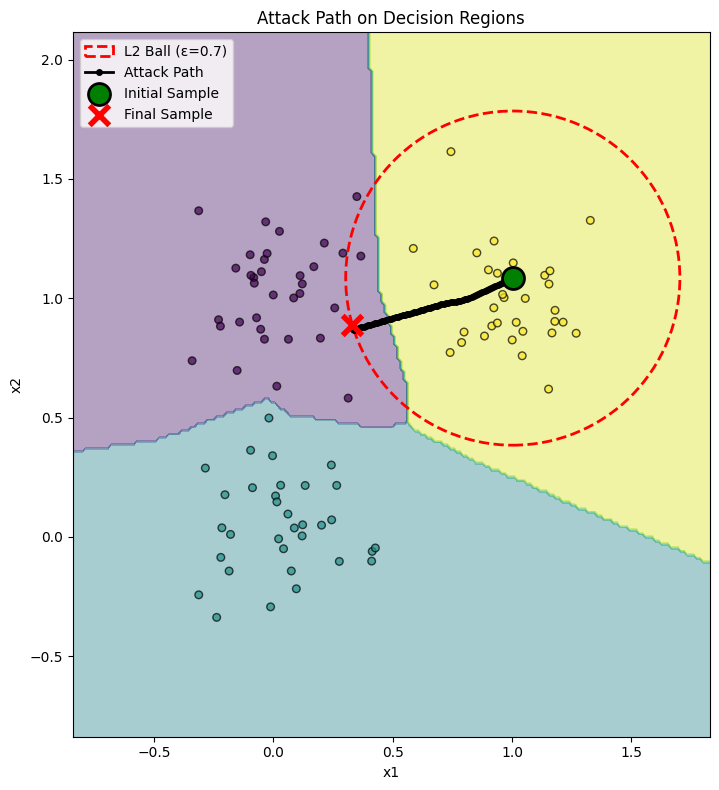

In [148]:
# Single sample attack with tracker

sample_tracker = Sample2DTracker()
native_attack = PGD(
    perturbation_model=perturbation_model,
    epsilon=epsilon,
    num_steps=num_iter,
    step_size=alpha,
    random_start=False,
    y_target=None,
    backend=Backends.NATIVE,
    trackers=[sample_tracker],
    ub=3,
    lb=-3,
)

adv_dataloader_singl = native_attack(secmlt_model, single_sample_loader)
secmlt_plot_attack_path(secmlt_model.model, X_test, y_test, X_test[0,:], sample_tracker.get(), epsilon, title="Attack Path on Decision Regions")

In [149]:
#dimension of ts_loader
print(len(ts_dataloader.dataset))
# dimension of adv_loader_single
print(len(adv_dataloader_single.dataset))
# dimesion of adv_loader_complete
print(len(adv_dataloader_complete.dataset))

100
1
100


### Exercise 2

* Try to change the random start parameter. What can you notice to the result of the attack?
* Try to change the epsilon value. What can you say about the performance of the attack?
* Compute the attack with SecML Torch and compute the accuracy of the attack. Is it enough to compute the robustness of a model?

In [150]:
from secmlt.metrics.classification import Accuracy

accuracy = Accuracy()(secmlt_model, ts_dataloader)

print("Test accuracy: {:.2f}%".format(accuracy * 100))
# 

accuracy = Accuracy()(secmlt_model, adv_dataloader_complete) # change espilon in complete dataset attack (view above)
 
print("Test accuracy adversarial examples: {:.2f}%".format(accuracy * 100))

# epsilon=0.548, --> 0% accuracy 
#  epsilon=0.546, --> 100% accuracy
  

Test accuracy: 100.00%
Test accuracy adversarial examples: 11.00%


### My Notes

**Accuracy and Epsilon**  
The accuracy of the model on adversarial examples depends on the epsilon value chosen for the attack.  
By increasing epsilon, the attack becomes stronger, and the accuracy of the model on adversarial examples decreases.

**is it enough to compute the robustness of a model?**

One evasive sample does not mean that the model is 'broken'.
Average robustness must be assessed over many examples and with various ε:

some points are close to the decision boundary → easy to attack;

others are far away → require stronger perturbations.


**Random_start parameter**

`random_start=False` 

In this case:  
- The attack starts exactly from the original input.  
- The first gradient step starts from a point on the edge or inside the L2 ball centered on the input.  
- The attack's trajectory is more regular and predictable.  

Visual Effect:
The attack's trajectory tends to be "straight," directed towards a different decision region.


**`random_start=True`**  
In this case:  
- The attack starts from a random point within the L2 sphere (radius epsilon) around the input.  
- From there, the gradient guides the path towards maximizing the loss.  

Advantages:
- Better exploration of the adversarial space.  
- Higher probability of finding a more effective adversarial point (especially if the model is somewhat robust).  

Visual Effect:
The trajectory appears more irregular or curved because it starts from a random point and adapts.   
Often, the endpoint is farther from the starting point.  

Disadvantages:  
- The attack is non-deterministic: running it multiple times can result in different trajectories and outcomes.

